Dataset loaded successfully. Initial shape: (120, 5)
Rohith John 24BAD100

--- Class Distribution (Entire Dataset) ---
Fraud
0    110
1     10
Name: count, dtype: int64
Fraud Percentage: 8.33%

--- Training Data Distribution (After SMOTE) ---
Fraud
1    88
0    88
Name: count, dtype: int64


Training model BEFORE SMOTE...
Training model AFTER SMOTE...

=== Performance BEFORE SMOTE ===
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24

=== Performance AFTER SMOTE ===
              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


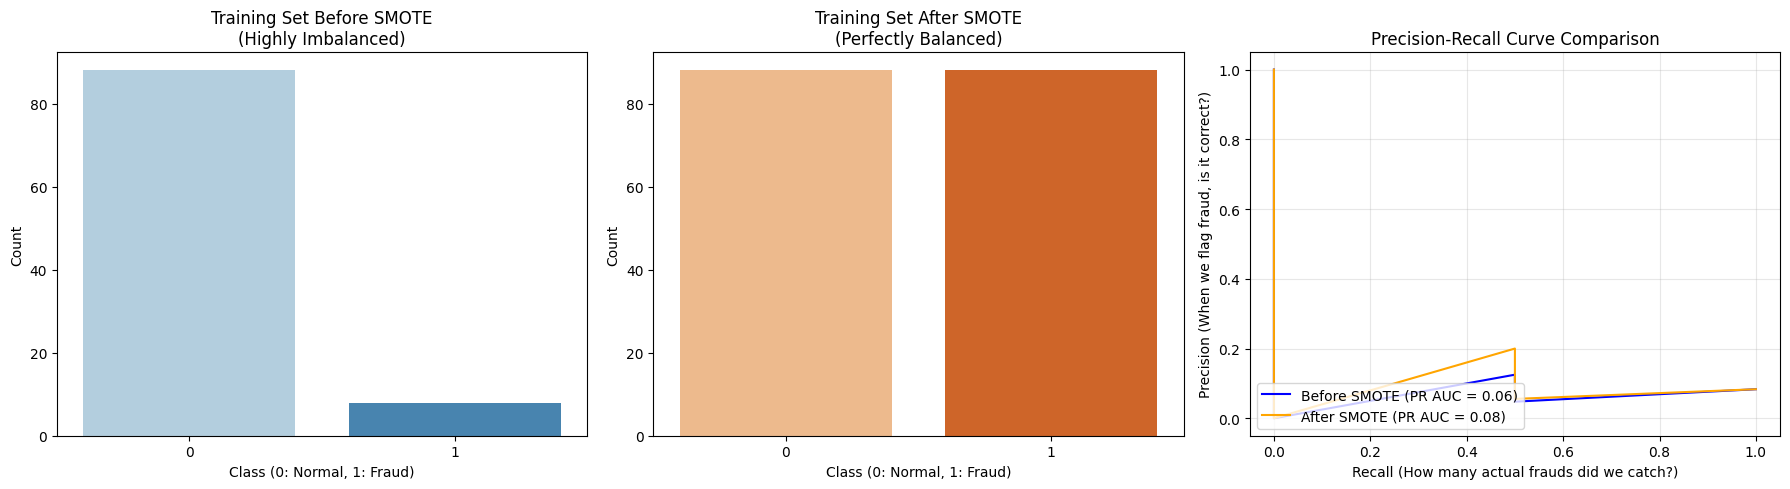

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE

# 1. Load the dataset
# REMINDER: Ensure 'fraud_smote.csv' is uploaded to your Colab session storage.
try:
    df = pd.read_csv('fraud_smote.csv')
    print(f"Dataset loaded successfully. Initial shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'fraud_smote.csv' not found. Please upload it to Colab.")
    raise
print("Rohith John 24BAD100")
# --- Robust Data Preprocessing ---
df.columns = df.columns.str.strip()

# Identify target column (commonly 'Fraud' or 'Class' in these datasets)
target_col = 'Fraud' if 'Fraud' in df.columns else 'Class'
if target_col not in df.columns:
    target_col = df.columns[-1] # Fallback to the last column
    print(f"Target column not explicitly found. Assuming it's '{target_col}'")

X = df.drop(target_col, axis=1)
y = df[target_col]

# Task 1: Check class imbalance
print("\n--- Class Distribution (Entire Dataset) ---")
print(y.value_counts())
print(f"Fraud Percentage: {(y.sum() / len(y)) * 100:.2f}%\n")

# Split data FIRST to prevent data leakage into the test set
# stratify=y ensures the 80/20 split maintains the same ratio of fraud to normal cases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Task 2: Apply SMOTE (ONLY to the training data)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("--- Training Data Distribution (After SMOTE) ---")
print(pd.Series(y_train_smote).value_counts())
print("\n")

# Task 3: Train models before & after SMOTE
# Using a lightweight Random Forest for good performance on fraud detection
print("Training model BEFORE SMOTE...")
model_before = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model_before.fit(X_train, y_train)
probs_before = model_before.predict_proba(X_test)[:, 1]
preds_before = model_before.predict(X_test)

print("Training model AFTER SMOTE...")
model_after = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
model_after.fit(X_train_smote, y_train_smote)
probs_after = model_after.predict_proba(X_test)[:, 1]
preds_after = model_after.predict(X_test)

# Task 4: Compare performance
print("\n=== Performance BEFORE SMOTE ===")
print(classification_report(y_test, preds_before))

print("=== Performance AFTER SMOTE ===")
print(classification_report(y_test, preds_after))

# ----------------- Visualizations -----------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Visualization 1: Class distribution Before SMOTE
sns.countplot(x=y_train, ax=axes[0], palette='Blues', hue=y_train, legend=False)
axes[0].set_title('Training Set Before SMOTE\n(Highly Imbalanced)')
axes[0].set_xlabel('Class (0: Normal, 1: Fraud)')
axes[0].set_ylabel('Count')

# Visualization 2: Class distribution After SMOTE
sns.countplot(x=y_train_smote, ax=axes[1], palette='Oranges', hue=y_train_smote, legend=False)
axes[1].set_title('Training Set After SMOTE\n(Perfectly Balanced)')
axes[1].set_xlabel('Class (0: Normal, 1: Fraud)')
axes[1].set_ylabel('Count')

# Visualization 3: Precision-Recall Curve
# PR curves are better than ROC curves for highly imbalanced data
precision_b, recall_b, _ = precision_recall_curve(y_test, probs_before)
auc_b = auc(recall_b, precision_b)

precision_a, recall_a, _ = precision_recall_curve(y_test, probs_after)
auc_a = auc(recall_a, precision_a)

axes[2].plot(recall_b, precision_b, label=f'Before SMOTE (PR AUC = {auc_b:.2f})', color='blue')
axes[2].plot(recall_a, precision_a, label=f'After SMOTE (PR AUC = {auc_a:.2f})', color='orange')
axes[2].set_title('Precision-Recall Curve Comparison')
axes[2].set_xlabel('Recall (How many actual frauds did we catch?)')
axes[2].set_ylabel('Precision (When we flag fraud, is it correct?)')
axes[2].legend(loc='lower left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()